# 05 — Model Evaluation

The model and its decision threshold were both frozen using the **validation**
split (notebook 04). This notebook opens the **test** split and scores it once.
Nothing here changes a parameter.

```bash
python -m src.pipeline --evaluate
python -m src.pipeline --ablations
```

In [1]:
import sys, warnings
from pathlib import Path

# Make the repository root importable no matter where Jupyter was launched from.
ROOT = Path.cwd()
while not (ROOT / "src" / "config.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 60)
warnings.filterwarnings("ignore", category=FutureWarning)

from src import config
print(f"Repository root : {ROOT}")
print(f"Random seed     : {config.RANDOM_STATE}")

Repository root : E:\AIM\AIM AI ML Capstone\AI_Capstone_Network_Intrusion_Detection
Random seed     : 42


In [2]:
def show(figure_name, caption=None):
    """Display a figure produced by the pipeline, or explain how to produce it."""
    path = config.FIGURES_DIR / f"{figure_name}.png"
    if path.exists():
        display(Image(filename=str(path)))
        if caption:
            display(Markdown(f"*{caption}*"))
    else:
        display(Markdown(
            f"> ⚠️ `figures/{figure_name}.png` not found. "
            "Run the pipeline stage noted above to generate it."))

In [3]:
import json

deployment_path = config.MODELS_DIR / "deployment.json"
if deployment_path.exists():
    deployment = json.loads(deployment_path.read_text(encoding="utf-8"))
    print("FROZEN DEPLOYMENT CONFIGURATION")
    print("=" * 60)
    for key, value in deployment.items():
        print(f"  {key:<22} {value}")
else:
    deployment = {}
    display(Markdown("> ⚠️ Run `python -m src.pipeline --evaluate` first."))

FROZEN DEPLOYMENT CONFIGURATION
  model_key              lightgbm
  display_name           LightGBM
  threshold              0.465
  selection_reason       Highest validation PR-AUC (0.9858), +0.0003 ahead of XGBoost (0.9855). Validation recall 0.9510, FPR 0.0762, throughput 82,396 flows/s.
  selected_on            validation split
  validation_pr_auc      0.985769
  random_state           42
  frozen_at              2026-09-16 21:17:10


## 1. Test-split results

Every metric the rubric asks for, plus MCC, balanced accuracy and Brier score.

In [4]:
test_path = config.METRICS_DIR / "test_metrics_main.csv"
test = pd.read_csv(test_path, index_col=0) if test_path.exists() else None

if test is not None:
    headline = ["display_name", "accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]
    display(Markdown("### Detection quality"))
    display(test[[c for c in headline if c in test.columns]]
            .style.format({c: "{:.4f}" for c in headline[1:]}))

    operational = ["display_name", "false_positive_rate", "false_negative_rate",
                   "tp", "fn", "fp", "tn"]
    display(Markdown("### Operational error rates and confusion counts"))
    display(test[[c for c in operational if c in test.columns]]
            .style.format({"false_positive_rate": "{:.3%}",
                           "false_negative_rate": "{:.3%}",
                           "tp": "{:,.0f}", "fn": "{:,.0f}",
                           "fp": "{:,.0f}", "tn": "{:,.0f}"}))

    cost = ["display_name", "fit_seconds", "search_seconds",
            "throughput_flows_per_second", "inference_ms_per_1k_rows"]
    display(Markdown("### Computational cost"))
    display(test[[c for c in cost if c in test.columns]])

### Detection quality

,display_name,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,,
logistic_regression,Logistic Regression,0.7442,0.5901,0.9517,0.7285,0.9193,0.8789
random_forest,Random Forest,0.8244,0.6784,0.9752,0.8002,0.9669,0.9493
xgboost,XGBoost,0.8231,0.6800,0.9622,0.7968,0.9673,0.9526
lightgbm,LightGBM,0.8148,0.6695,0.9604,0.7890,0.9648,0.9485
isolation_forest,Isolation Forest,0.6469,0.5164,0.3265,0.4001,0.6795,0.5047


### Operational error rates and confusion counts

,display_name,false_positive_rate,false_negative_rate,tp,fn,fp,tn
model,,,,,,,
logistic_regression,Logistic Regression,37.273%,4.831%,"18,065",917,"12,547","21,115"
random_forest,Random Forest,26.068%,2.481%,"18,511",471,"8,775","24,887"
xgboost,XGBoost,25.536%,3.777%,"18,265",717,"8,596","25,066"
lightgbm,LightGBM,26.736%,3.956%,"18,231",751,"9,000","24,662"
isolation_forest,Isolation Forest,17.242%,67.348%,"6,198","12,784","5,804","27,858"


### Computational cost

,display_name,fit_seconds,search_seconds,throughput_flows_per_second,inference_ms_per_1k_rows
model,,,,,
logistic_regression,Logistic Regression,6.852,89.27,280200.1,3.569
random_forest,Random Forest,16.620,1441.47,83001.0,12.048
xgboost,XGBoost,4.683,726.82,141012.3,7.092
lightgbm,LightGBM,8.017,768.18,82395.8,12.137
isolation_forest,Isolation Forest,0.951,NaN,58669.2,17.045


### Why accuracy is reported but never used to decide anything

On a corpus where attacks are ~44% of records, accuracy compresses every model
into a narrow band and rewards majority-class performance. The metrics that
carry the decision are:

- **Recall** — what fraction of intrusions do we catch?
- **FNR** — its complement, and the number that maps to residual security risk.
- **FPR** — analyst workload, and the *only* workload metric that transfers to a
  different base rate.
- **PR-AUC** — threshold-free ranking quality on the positive class.

## 2. Confusion matrices

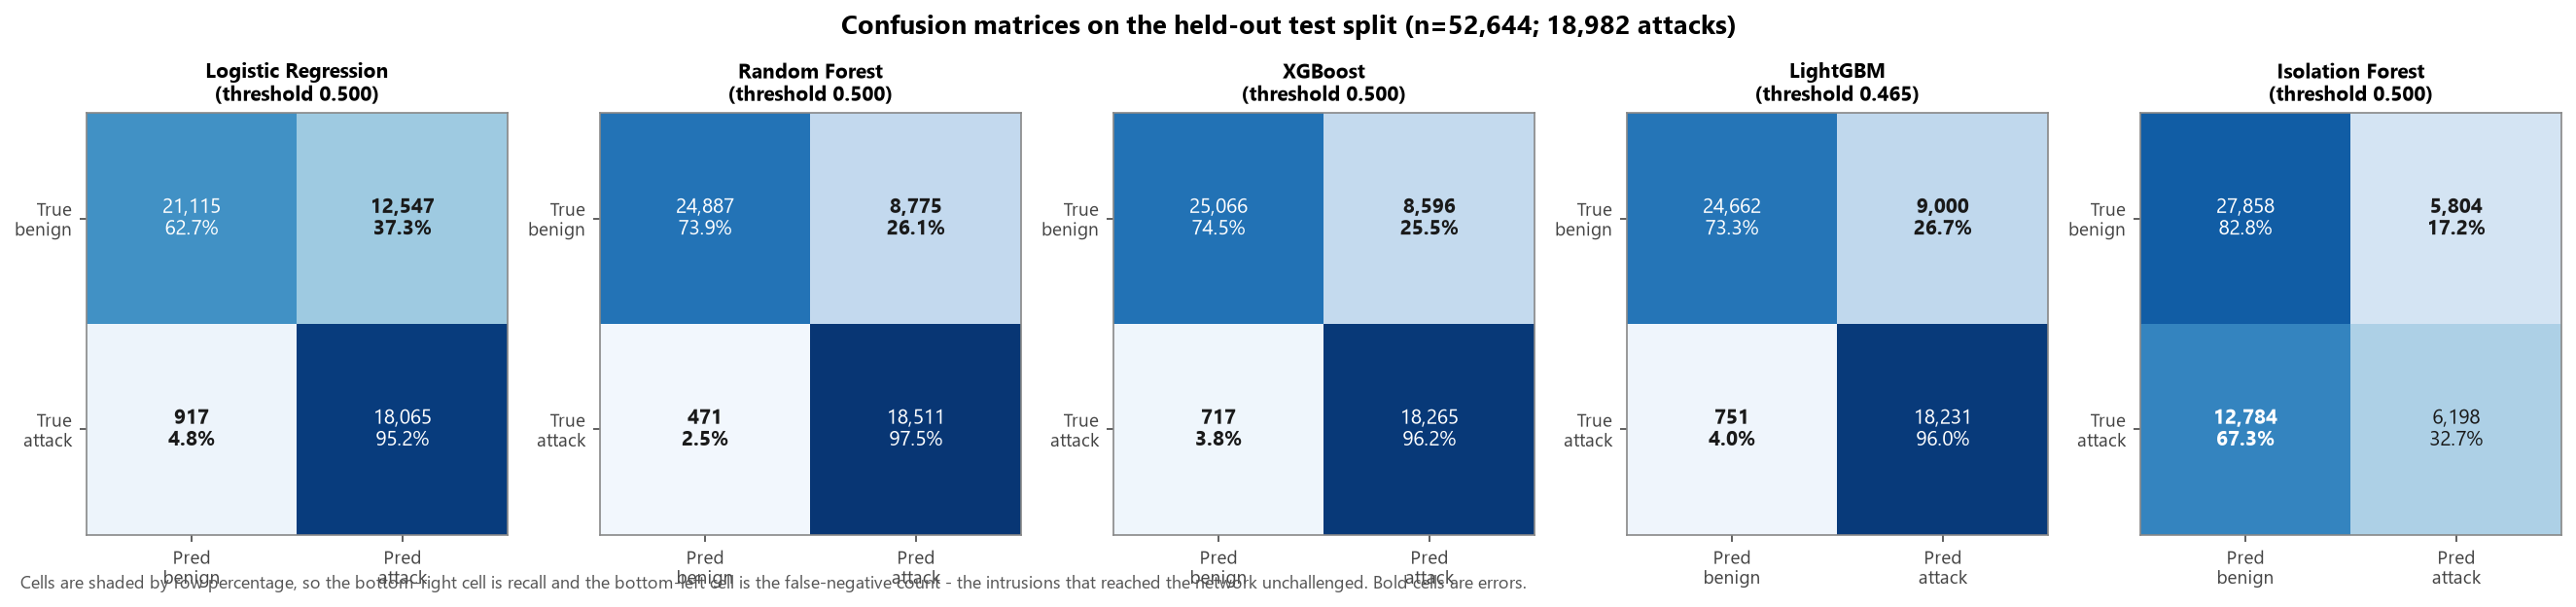

In [5]:
show("fig14_confusion_matrices")

The bottom-left cell of each matrix is the count of intrusions that reached the
network unchallenged. That cell, not the diagonal, is what a SOC lead reads
first.

## 3. ROC and Precision-Recall curves

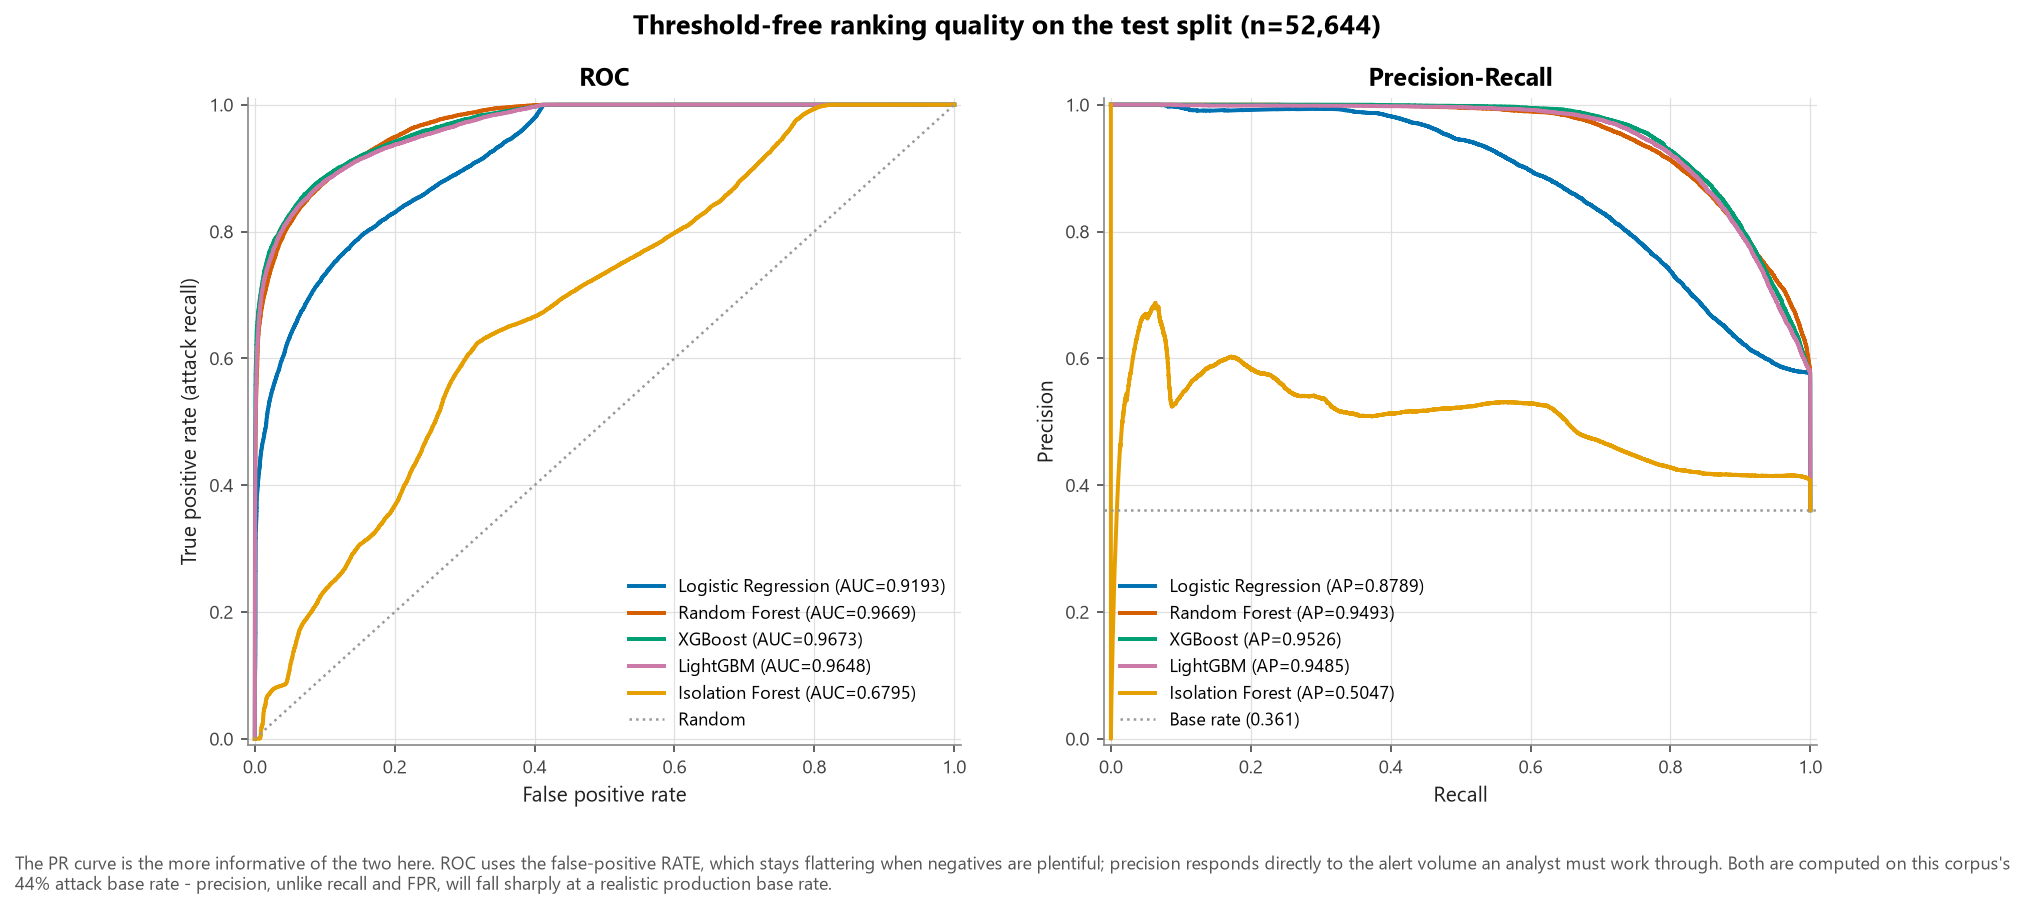

In [6]:
show("fig15_roc_pr_curves")

**The PR curve is the more informative of the two here.** ROC uses the
false-positive *rate*, which stays flattering when negatives are plentiful.
Precision responds directly to the alert volume an analyst must work through.

Both are computed at this corpus's 44% attack base rate. Precision — unlike
recall and FPR — will fall sharply at a realistic production base rate.

## 4. Model comparison

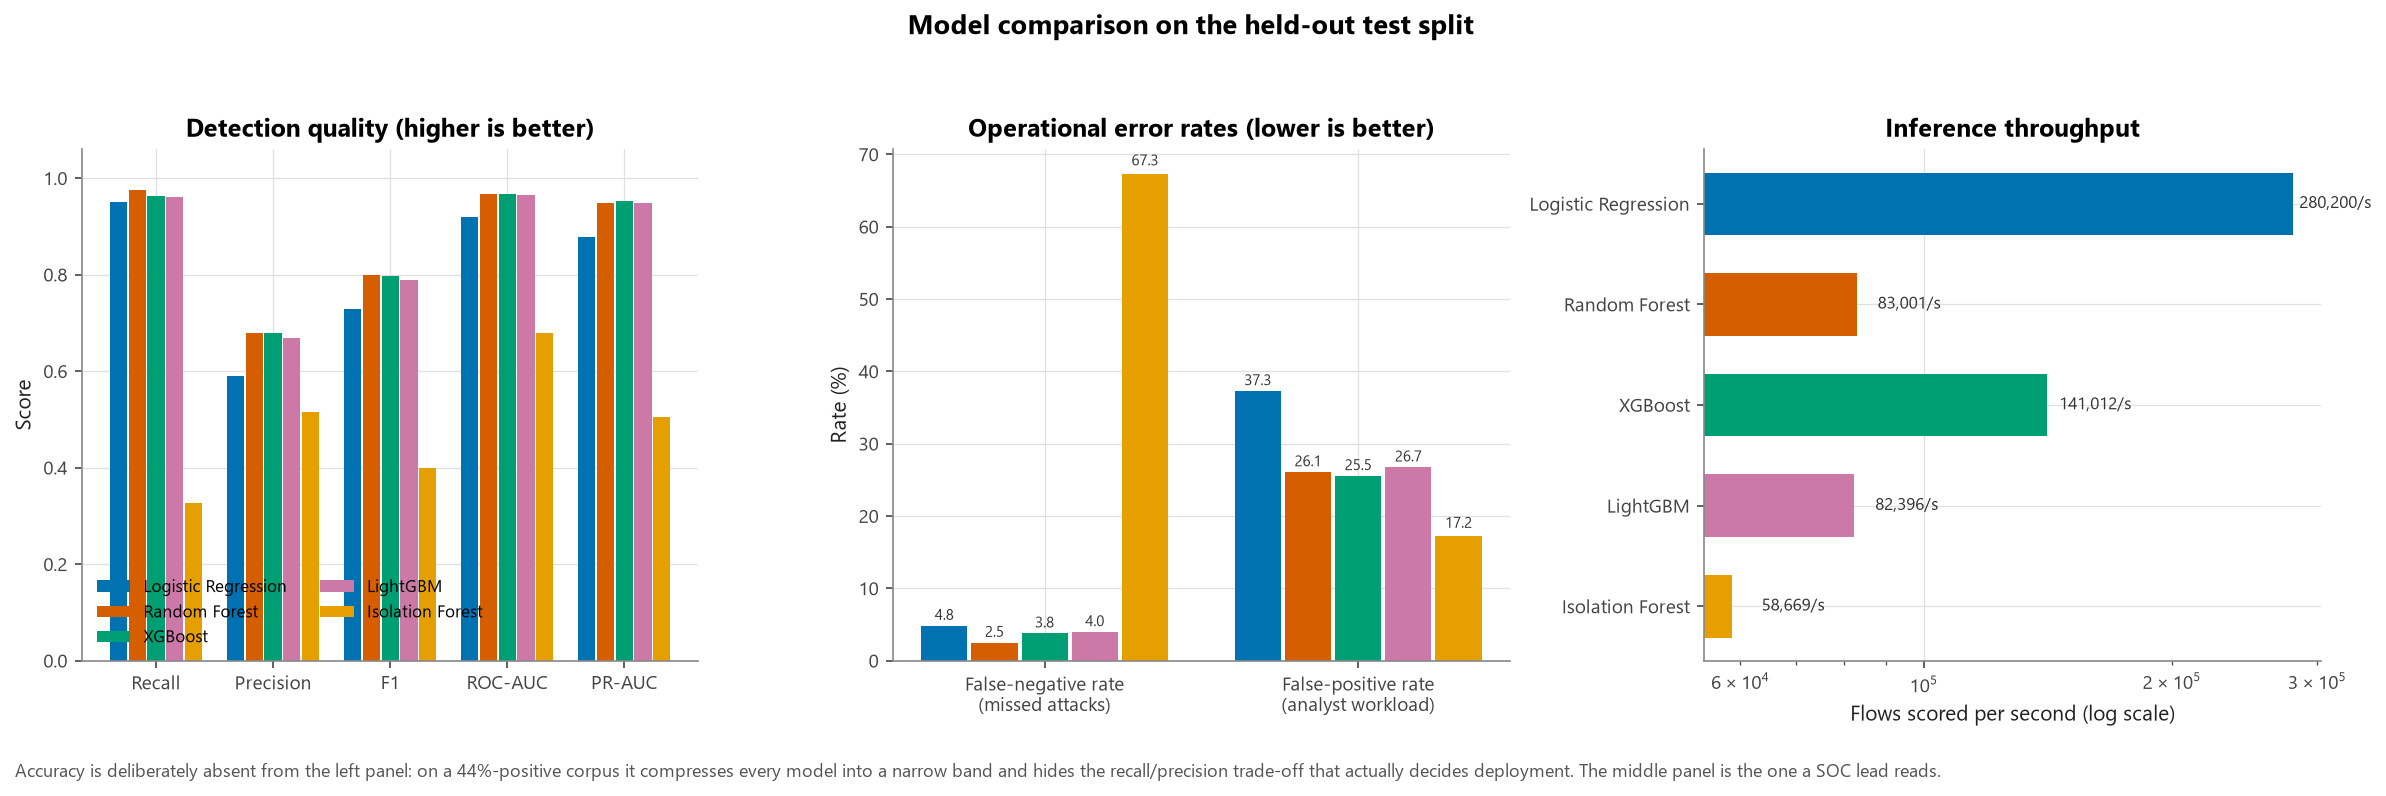

In [7]:
show("fig16_model_comparison")

In [8]:
if deployment:
    display(Markdown(
        f"### Selected: **{deployment['display_name']}**\n\n"
        f"{deployment['selection_reason']}"))

### Selected: **LightGBM**

Highest validation PR-AUC (0.9858), +0.0003 ahead of XGBoost (0.9855). Validation recall 0.9510, FPR 0.0762, throughput 82,396 flows/s.

**Selection used validation PR-AUC — deliberately not accuracy.** PR-AUC measures
how well a model *ranks* attacks above benign flows across all thresholds, on the
positive class only. That is the quantity that survives a change of base rate,
and the one that determines whether a useful operating point exists at all.

## 5. Threshold analysis — 0.50 is a default, not an optimum

The sweep below was computed on the **validation** split. Choosing a threshold is
a fitting decision; doing it on test would make the reported test metrics
optimistic.

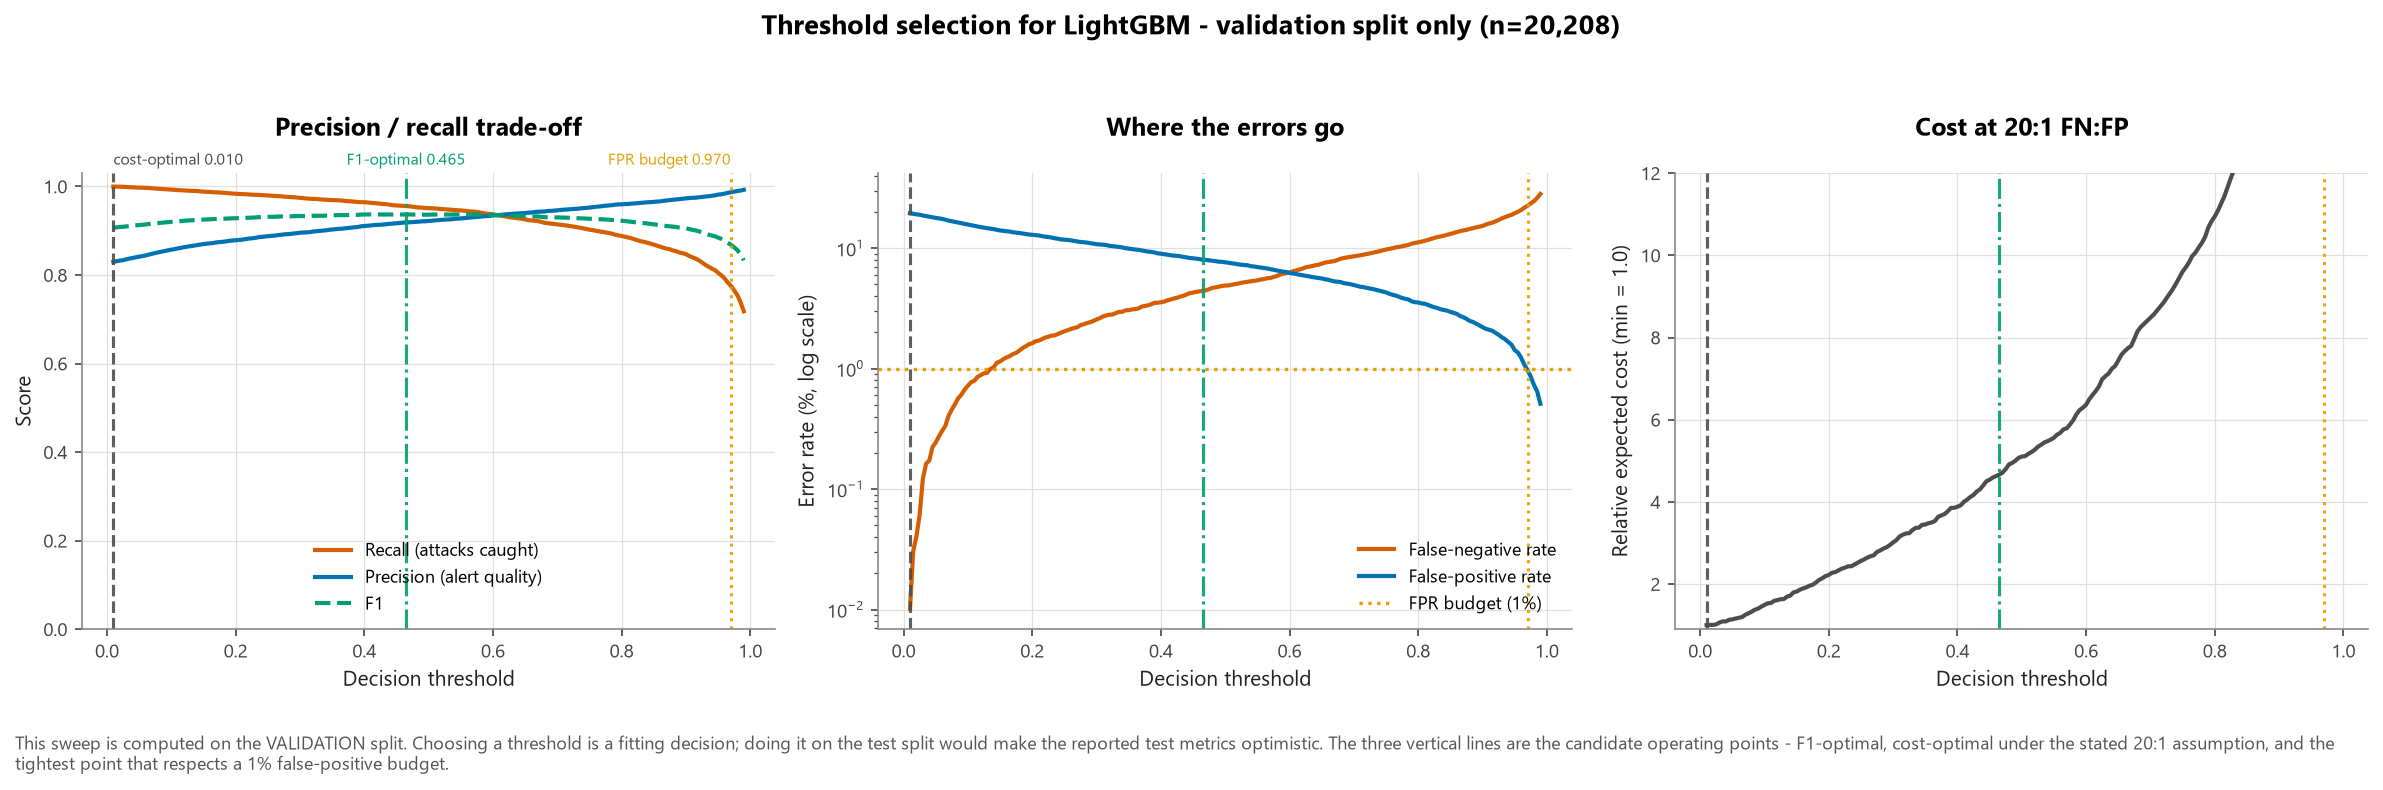

In [9]:
show("fig17_threshold_analysis")

In [10]:
recommendation_path = config.METRICS_DIR / "threshold_recommendation_main.json"
if recommendation_path.exists():
    recommendation = json.loads(recommendation_path.read_text(encoding="utf-8"))
    rows = []
    for name in ("max_f1", "min_cost", "fpr_constrained"):
        if name in recommendation:
            rows.append({"operating_point": name, **recommendation[name]})
    display(pd.DataFrame(rows).set_index("operating_point")
            .style.format({"threshold": "{:.3f}", "recall": "{:.4f}",
                           "precision": "{:.4f}", "f1": "{:.4f}",
                           "false_positive_rate": "{:.3%}",
                           "false_negative_rate": "{:.3%}"}))

    display(Markdown("**Sensitivity of the cost-optimal threshold to the cost assumption**"))
    display(pd.DataFrame(recommendation["cost_ratio_sensitivity"]).T
            .style.format({"threshold": "{:.3f}", "recall": "{:.4f}",
                           "false_positive_rate": "{:.3%}"}))

,threshold,recall,precision,f1,false_positive_rate,false_negative_rate
operating_point,,,,,,
max_f1,0.465,0.9558,0.9189,0.9370,8.009%,4.418%
min_cost,0.010,0.9999,0.8295,0.9068,19.521%,0.010%
fpr_constrained,0.970,0.7754,0.9869,0.8685,0.975%,22.458%


**Sensitivity of the cost-optimal threshold to the cost assumption**

,threshold,recall,false_positive_rate
ratio_5,0.065,0.9966,17.225%
ratio_10,0.020,0.9996,19.078%
ratio_20,0.010,0.9999,19.521%
ratio_50,0.010,0.9999,19.521%
ratio_100,0.010,0.9999,19.521%


The 20:1 false-negative-to-false-positive cost ratio is an **assumption, stated
openly, not a measurement**. Published breach-cost studies imply ratios in the
hundreds — but a detector tuned at that ratio alerts on nearly everything and
destroys itself through alert fatigue, so 20:1 is used as a deliberately
conservative working figure with its sensitivity reported.

**Which point should a SOC run?** A team with analyst capacity to spare should
take the F1-optimal point. A team already at queue capacity should take the
FPR-constrained point and pair the model with compensating controls. This is a
business decision about alert budget, not a modelling one.

In [11]:
operating_path = config.METRICS_DIR / "operating_points_main.json"
if operating_path.exists():
    points = json.loads(operating_path.read_text(encoding="utf-8"))
    frame = pd.DataFrame(points).T[
        ["threshold", "recall", "precision", "f1",
         "false_positive_rate", "false_negative_rate", "fn", "fp"]]
    display(Markdown("### The selected model at each operating point — on the TEST split"))
    display(frame.style.format({
        "threshold": "{:.3f}", "recall": "{:.4f}", "precision": "{:.4f}",
        "f1": "{:.4f}", "false_positive_rate": "{:.3%}",
        "false_negative_rate": "{:.3%}", "fn": "{:,.0f}", "fp": "{:,.0f}"}))

### The selected model at each operating point — on the TEST split

,threshold,recall,precision,f1,false_positive_rate,false_negative_rate,fn,fp
adopted_f1_optimal,0.465,0.9604,0.6695,0.7890,26.736%,3.956%,751,"9,000"
fpr_constrained,0.970,0.8336,0.8895,0.8607,5.840%,16.637%,"3,158","1,966"
default_0.50,0.500,0.9565,0.6779,0.7935,25.622%,4.351%,826,"8,625"


## 6. Ablations — what is the headline number actually measuring?

Each row is a **separate end-to-end experiment** with its own split, reusing the
hyper-parameters tuned in the main run so that exactly one thing changes at a
time.

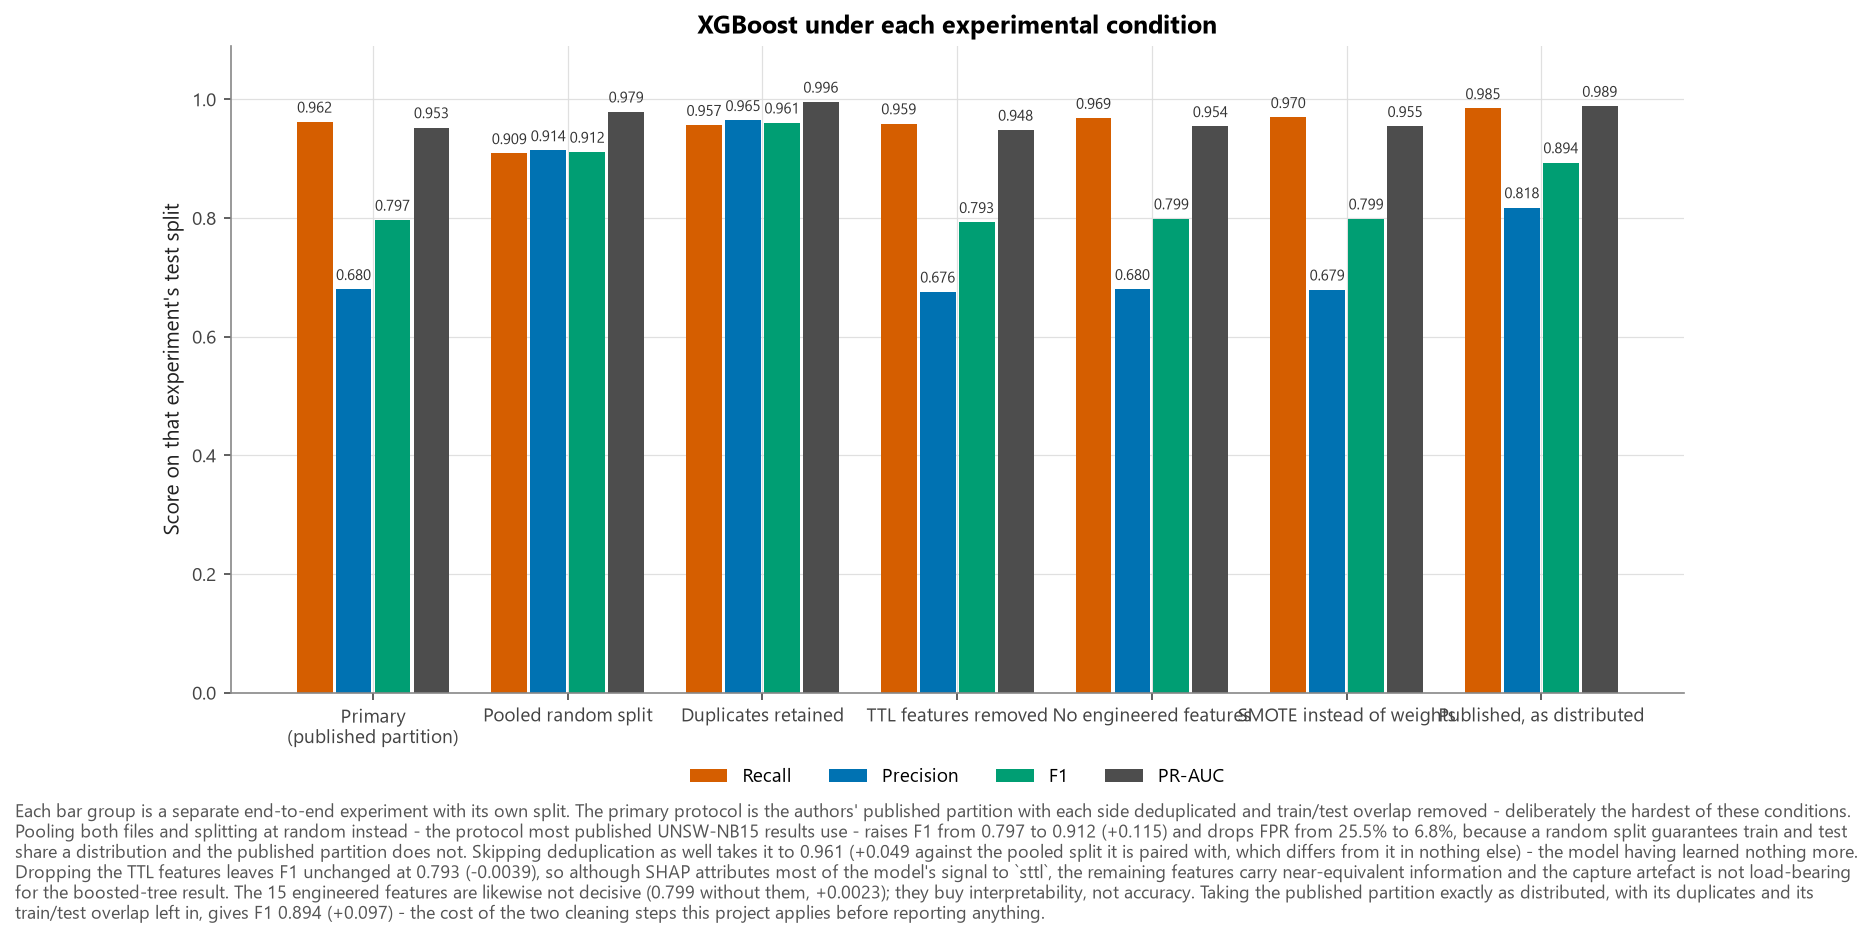

In [12]:
show("fig19_ablation_comparison")

In [13]:
ablation_path = config.METRICS_DIR / "ablation_summary.csv"
if ablation_path.exists() and deployment:
    ablations = pd.read_csv(ablation_path, index_col=[0, 1])
    best = deployment["model_key"]
    if best in ablations.index.get_level_values(1):
        sub = ablations.xs(best, level=1)[
            ["recall", "precision", "f1", "pr_auc",
             "false_positive_rate", "false_negative_rate"]]
        display(sub.style.format({
            "recall": "{:.4f}", "precision": "{:.4f}", "f1": "{:.4f}",
            "pr_auc": "{:.4f}", "false_positive_rate": "{:.3%}",
            "false_negative_rate": "{:.3%}"}))
else:
    display(Markdown("> Run `python -m src.pipeline --ablations` to populate this."))

,recall,precision,f1,pr_auc,false_positive_rate,false_negative_rate
experiment,,,,,,
main,0.9604,0.6695,0.7890,0.9485,26.736%,3.956%
pooled_random,0.9022,0.9211,0.9116,0.9793,6.165%,9.779%
keep_duplicates,0.9516,0.9732,0.9623,0.9959,4.645%,4.843%
no_ttl,0.9606,0.6567,0.7801,0.9441,28.320%,3.941%
no_engineered,0.9625,0.6736,0.7925,0.9484,26.303%,3.751%
smote,0.9652,0.6633,0.7863,0.9486,27.633%,3.477%
official_split_raw,0.9799,0.8164,0.8907,0.9872,26.997%,2.012%


### How to read this table

| Experiment | The question it answers |
|---|---|
| `main` | The primary protocol: the authors' published partition, each side deduplicated and train/test overlap removed. |
| `pooled_random` | How much easier is the pooled random split that most published results use? |
| `keep_duplicates` | How much are published UNSW-NB15 benchmarks inflated by repeated records? |
| `no_ttl` | How much of the score is *testbed recognition* rather than *attack detection*? |
| `no_engineered` | What did the 15 constructed features actually contribute? |
| `smote` | Does synthetic oversampling beat class weighting here, or not? |
| `official_split_raw` | What are the two cleaning steps worth, against the partition as distributed? |

This table is what separates "the model detects attacks" from "the model detects
this dataset."

---

**Next:** [`06_explainability_bias_audit.ipynb`](06_explainability_bias_audit.ipynb)